In [1]:
!pip install transformers torch pandas scikit-learn

import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm

# Thiết lập device sử dụng GPU T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


Bước 2: Xử lý dữ liệu JSON
Trong bài toán phân loại, ta cần chuyển các nhãn 0.0, 0.5, 1.0 thành các chỉ số class 0, 1, 2 tương ứng để tương thích với hàm Loss (CrossEntropy).

In [2]:
# Giả sử file của bạn tên là data.json
with open('labeled_results_all_v5.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Hàm chuyển đổi điểm số thành class index (0: Tiêu cực, 1: Trung tính, 2: Tích cực)
def map_label(value):
    if value == 0.0: return 0
    elif value == 0.5: return 1
    elif value == 1.0: return 2
    return 1 # Default về trung tính nếu có lỗi

processed_data = []
for item in raw_data:
    text = item['original_data']['textTranslated']
    # Lấy nhãn, nếu không có thì mặc định là 1 (Trung tính)
    labels = {l['name']: map_label(l['value']) for l in item['labels']}

    processed_data.append({
        'text': text,
        'Food quality': labels.get('Food quality', 1),
        'Price': labels.get('Price', 1),
        'Service quality': labels.get('Service quality', 1),
        'Atmosphere': labels.get('Atmosphere', 1)
    })

df = pd.DataFrame(processed_data)

# Chia tập Train/Val (80/20)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

Bước 3: Định nghĩa Dataset và Tokenizer
Chúng ta sẽ sử dụng Tokenizer của vinai/phobert-base-v2

In [3]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")
class RestaurantReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

        self.texts = df['text'].values
        # Chỉ lấy 4 tiêu chí
        self.aspect_labels = df[['Food quality', 'Price', 'Service quality', 'Atmosphere']].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = str(self.texts[index])
        labels = self.aspect_labels[index]

        # SỬA LỖI TẠI ĐÂY: Gọi trực tiếp tokenizer thay vì dùng .encode_plus()
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }
BATCH_SIZE = 16
# Khởi tạo lại Dataset và DataLoader sau khi sửa code
train_dataset = RestaurantReviewDataset(train_df, tokenizer)
val_dataset = RestaurantReviewDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Bước 4: Xây dựng cấu trúc mô hình Multi-task PhoBERT
Mô hình sẽ sử dụng chung phần Encoder của PhoBERT, sau đó phân tách ra 5 bộ phân loại (classifiers) để tối ưu cho 5 tiêu chí đánh giá

In [4]:
class PhoBertABSA(nn.Module):
    def __init__(self, n_classes=3, n_aspects=4):
        super(PhoBertABSA, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.drop = nn.Dropout(p=0.3)

        # 4 Linear classifiers cho 4 khía cạnh
        self.classifiers = nn.ModuleList([
            nn.Linear(self.phobert.config.hidden_size, n_classes) for _ in range(n_aspects)
        ])

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = self.drop(outputs.pooler_output)

        logits = [classifier(pooled_output) for classifier in self.classifiers]
        return logits

model = PhoBertABSA()
model = model.to(device)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Bước 5: Đánh giá mô hình.  Thiết lập vòng lặp Huấn luyện (Training Loop)Để cho ra kết quả tốt nhất trên dữ liệu mất cân bằng nhẹ, chúng ta sẽ kết hợp hàm Loss chuẩn và chỉ số Learning Rate tối ưu khoảng $2 \times 10^{-5}$ đến $5 \times 10^{-5}$.


Epoch 1/4


Validation: 100%|██████████| 280/280 [00:59<00:00,  4.73it/s]


Train Loss: 1.4428 | Train Acc: 0.8750
Val Loss:   1.0100 | Val Acc:   0.9117

Epoch 2/4


Validation: 100%|██████████| 280/280 [00:59<00:00,  4.73it/s]


Train Loss: 0.7780 | Train Acc: 0.9328
Val Loss:   0.7916 | Val Acc:   0.9302

Epoch 3/4


Validation: 100%|██████████| 280/280 [00:59<00:00,  4.73it/s]


Train Loss: 0.5954 | Train Acc: 0.9473
Val Loss:   0.7794 | Val Acc:   0.9335

Epoch 4/4


Validation: 100%|██████████| 280/280 [00:59<00:00,  4.73it/s]


Train Loss: 0.4549 | Train Acc: 0.9609
Val Loss:   0.7846 | Val Acc:   0.9346


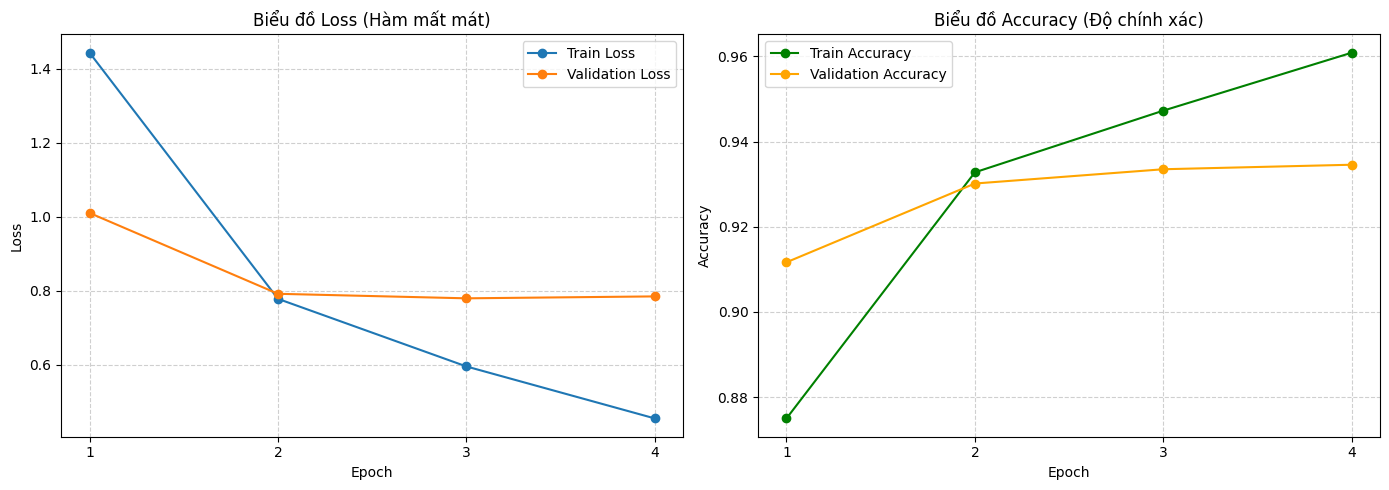

In [5]:
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# Khởi tạo lại Optimizer và Loss function
EPOCHS = 4
LEARNING_RATE = 2e-5
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

# 1. HÀM HUẤN LUYỆN (Cập nhật thêm tính Accuracy)
def train_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)

        loss = 0
        for i in range(4):
            loss += loss_fn(logits[i], labels[:, i])

            # Tính số lượng dự đoán đúng
            preds = torch.argmax(logits[i], dim=1)
            total_correct += (preds == labels[:, i]).sum().item()
            total_samples += labels.size(0) # batch_size

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    avg_acc = total_correct / total_samples # Tổng hợp Accuracy của cả 4 tiêu chí
    return avg_loss, avg_acc

# 2. HÀM ĐÁNH GIÁ TRÊN TẬP VALIDATION
def val_epoch(model, data_loader, loss_fn, device):
    model.eval() # Chuyển mô hình sang chế độ đánh giá
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad(): # Không tính gradient để tiết kiệm bộ nhớ và thời gian
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)

            loss = 0
            for i in range(4):
                loss += loss_fn(logits[i], labels[:, i])

                preds = torch.argmax(logits[i], dim=1)
                total_correct += (preds == labels[:, i]).sum().item()
                total_samples += labels.size(0)

            total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

# 3. VÒNG LẶP HUẤN LUYỆN VÀ LƯU TRỮ LỊCH SỬ
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, loss_fn, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Lưu vào history để vẽ biểu đồ
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

# 4. VẼ BIỂU ĐỒ TRỰC QUAN
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Biểu đồ Loss (Hàm mất mát)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o', color='green')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o', color='orange')
plt.title('Biểu đồ Accuracy (Độ chính xác)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
def print_confusion_matrix_tables(all_labels, all_preds):
    aspect_names = ['Food quality', 'Price', 'Service quality', 'Atmosphere']
    class_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']

    for i in range(4):
        # Tính toán ma trận nhầm lẫn
        cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])

        # Tạo DataFrame để hiển thị đẹp dưới dạng bảng
        df_cm = pd.DataFrame(
            cm,
            index=[f'Thực tế {c}' for c in class_names],
            columns=[f'Dự đoán {c}' for c in class_names]
        )

        print(f"\n### 🎯 Bảng Confusion Matrix: {aspect_names[i]}")
        # Lệnh to_markdown() giúp in ra định dạng bảng cực kỳ dễ copy
        print(df_cm.to_markdown())
        print("\n" + "-"*60)

Đang đánh giá và vẽ biểu đồ Confusion Matrix...


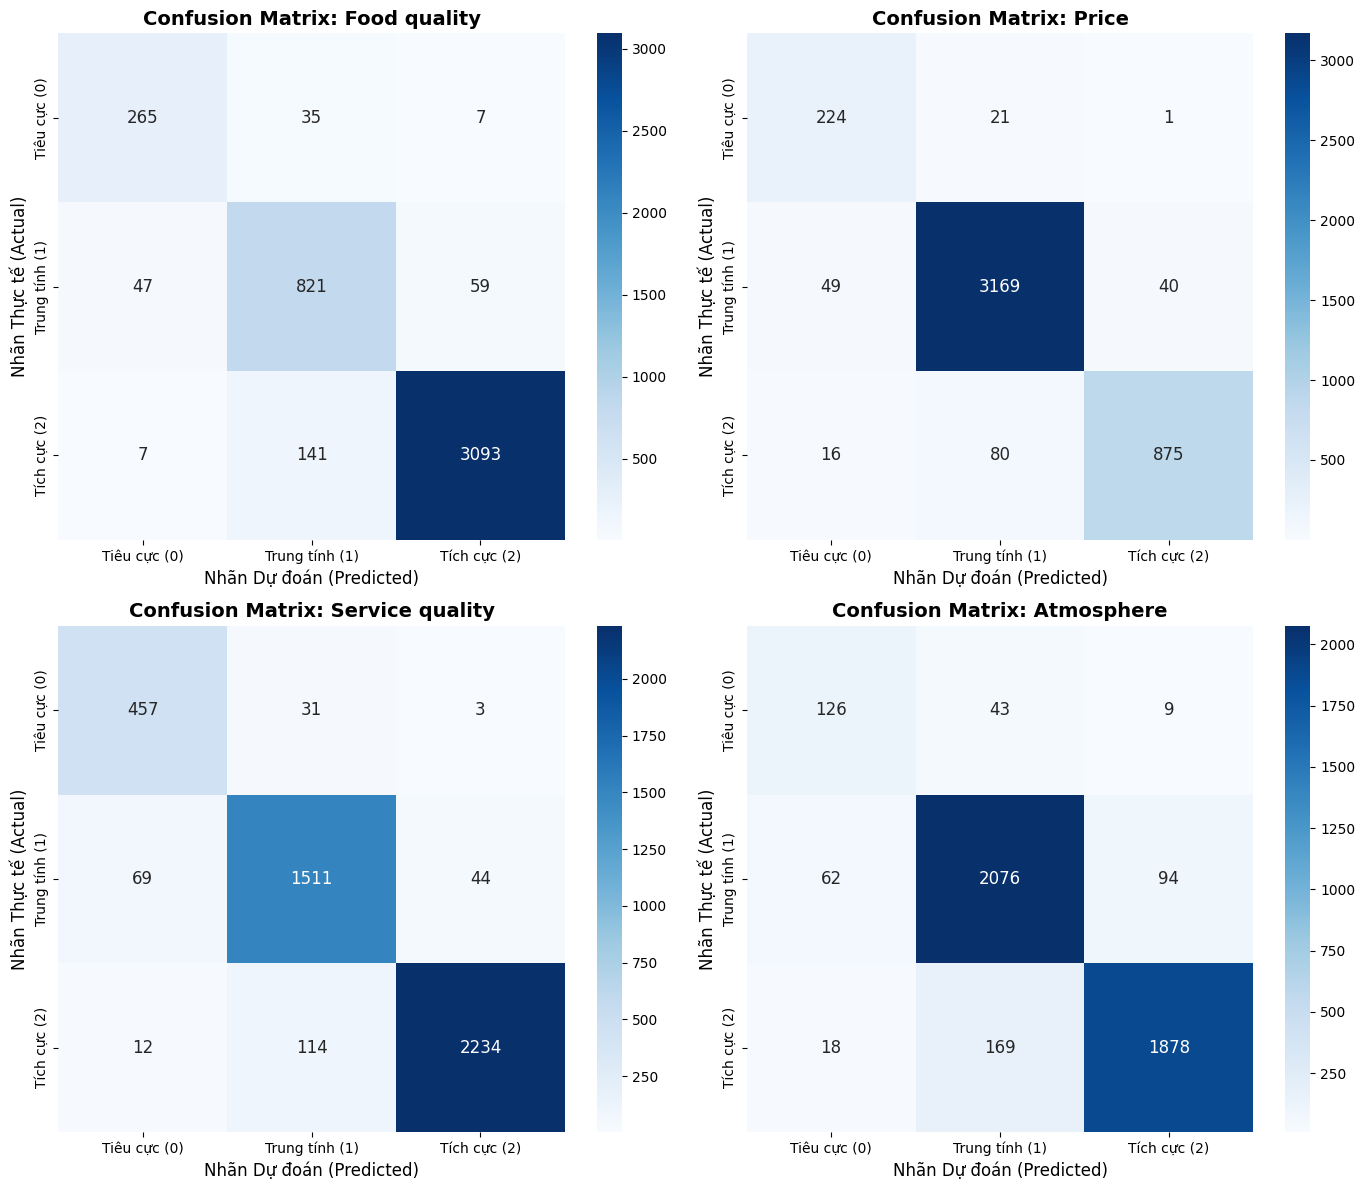

NameError: name 'all_labels' is not defined

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_and_plot_matrices(model, data_loader, device):
    model.eval()

    # Từ điển lưu trữ dự đoán và nhãn thực tế cho 4 khía cạnh
    all_preds = {0: [], 1: [], 2: [], 3: []}
    all_labels = {0: [], 1: [], 2: [], 3: []}

    aspect_names = ['Food quality', 'Price', 'Service quality', 'Atmosphere']
    class_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']

    # Thu thập toàn bộ dự đoán trên tập Validation
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)

            for i in range(4):
                # Lấy nhãn có xác suất cao nhất
                preds = torch.argmax(logits[i], dim=1).cpu().numpy()
                all_preds[i].extend(preds)
                all_labels[i].extend(labels[:, i].cpu().numpy())

    # Thiết lập khung vẽ 2x2
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i in range(4):
        # Tạo ma trận nhầm lẫn
        cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])

        # Vẽ Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=class_names, yticklabels=class_names,
                    annot_kws={"size": 12}) # Chỉnh cỡ chữ số bên trong

        axes[i].set_title(f'Confusion Matrix: {aspect_names[i]}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Nhãn Dự đoán (Predicted)', fontsize=12)
        axes[i].set_ylabel('Nhãn Thực tế (Actual)', fontsize=12)

    plt.tight_layout()
    plt.show()

# Gọi hàm để vẽ biểu đồ trên tập Validation
print("Đang đánh giá và vẽ biểu đồ Confusion Matrix...")
evaluate_and_plot_matrices(model, val_loader, device)
print_confusion_matrix_tables(all_labels, all_preds)

Đang sử dụng thiết bị: cuda

--- BƯỚC 2: Đọc và xử lý dữ liệu ---

--- BƯỚC 3: Khởi tạo Dataset (Tăng Batch Size) ---

--- BƯỚC 4: Khởi tạo mô hình PhoBERT ABSA ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- BƯỚC 5: Bắt đầu quá trình huấn luyện (Đã Nâng Cấp) ---

Epoch 1/5


Validation: 100%|██████████| 140/140 [01:02<00:00,  2.26it/s]


...

Train Loss: 0.7085 | Train Acc: 0.9480
Val Loss:   0.8862 | Val Acc:   0.9292
-> Val Loss giảm từ 0.9328 xuống 0.8862. Đang lưu mô hình...

Epoch 4/5


Validation: 100%|██████████| 140/140 [01:02<00:00,  2.26it/s]


Train Loss: 0.5096 | Train Acc: 0.9637
Val Loss:   0.9173 | Val Acc:   0.9337

Epoch 5/5


Validation: 100%|██████████| 140/140 [01:02<00:00,  2.26it/s]


Train Loss: 0.3779 | Train Acc: 0.9741
Val Loss:   0.9142 | Val Acc:   0.9358

--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---


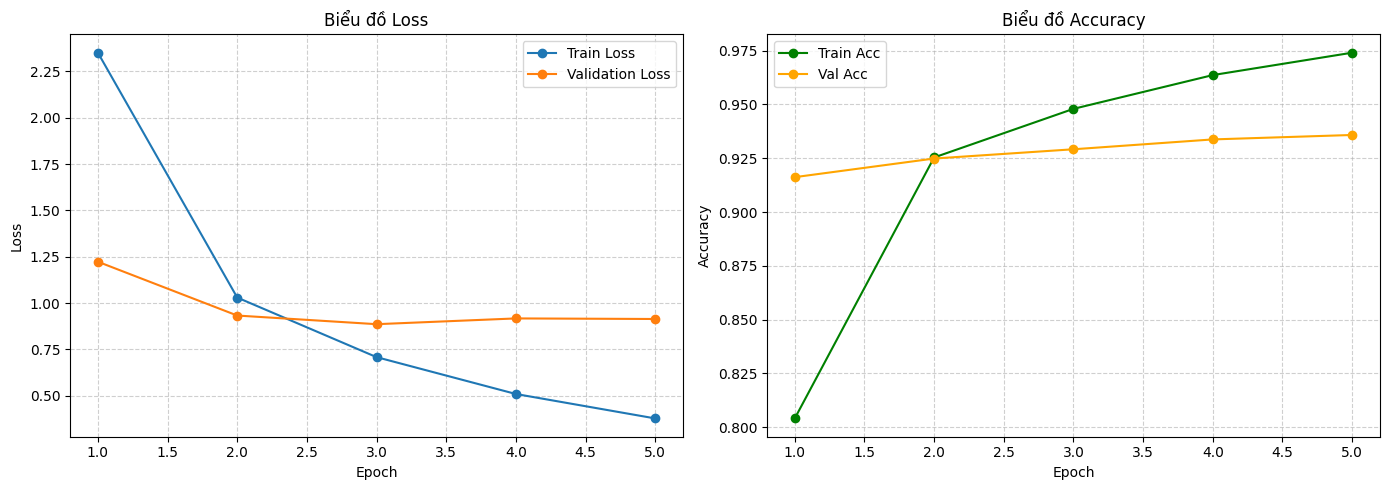

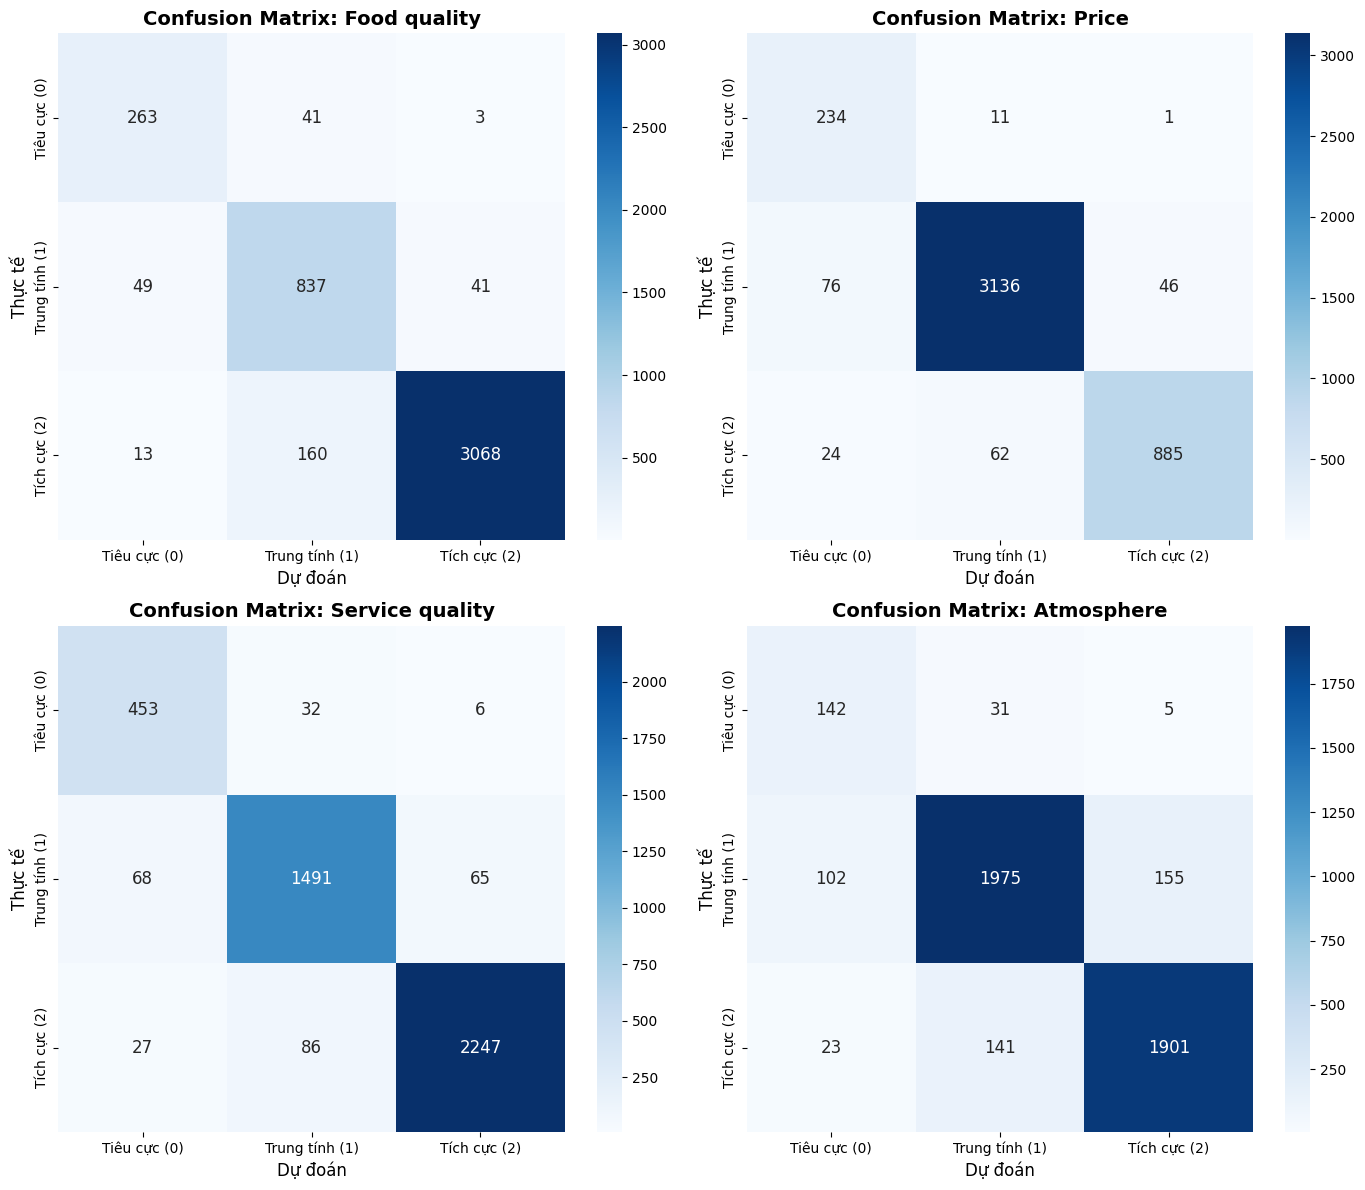


BẢNG CONFUSION MATRIX DÀNH CHO BÁO CÁO (MARKDOWN)

### 🎯 Food quality
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    263 |                       41 |                      3 |
| Thực tế Trung tính (1) |                     49 |                      837 |                     41 |
| Thực tế Tích cực (2)   |                     13 |                      160 |                   3068 |

### 🎯 Price
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    234 |                       11 |                      1 |
| Thực tế Trung tính (1) |                     76 |                     3136 |      

In [14]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup

# Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# ==========================================
# BƯỚC 2: XỬ LÝ DỮ LIỆU
# ==========================================
print("\n--- BƯỚC 2: Đọc và xử lý dữ liệu ---")
with open('labeled_results_all_v5.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

def map_label(value):
    if value == 0.0: return 0
    elif value == 0.5: return 1
    elif value == 1.0: return 2
    return 1

processed_data = []
for item in raw_data:
    text = item['original_data']['textTranslated']
    labels = {l['name']: map_label(l['value']) for l in item['labels']}

    processed_data.append({
        'text': text,
        'Food quality': labels.get('Food quality', 1),
        'Price': labels.get('Price', 1),
        'Service quality': labels.get('Service quality', 1),
        'Atmosphere': labels.get('Atmosphere', 1)
    })

df = pd.DataFrame(processed_data)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 3: DATASET & DATALOADER
# ==========================================
print("\n--- BƯỚC 3: Khởi tạo Dataset (Tăng Batch Size) ---")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class RestaurantReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.texts = df['text'].values
        self.aspect_labels = df[['Food quality', 'Price', 'Service quality', 'Atmosphere']].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = str(self.texts[index])
        labels = self.aspect_labels[index]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# TĂNG BATCH SIZE LÊN 32 ĐỂ TẬN DỤNG TỐI ĐA GPU T4
BATCH_SIZE = 32

train_dataset = RestaurantReviewDataset(train_df, tokenizer)
val_dataset = RestaurantReviewDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ==========================================
# BƯỚC 4: KHỞI TẠO MÔ HÌNH
# ==========================================
print("\n--- BƯỚC 4: Khởi tạo mô hình PhoBERT ABSA ---")
class PhoBertABSA(nn.Module):
    def __init__(self, n_classes=3, n_aspects=4):
        super(PhoBertABSA, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.drop = nn.Dropout(p=0.3)
        self.classifiers = nn.ModuleList([
            nn.Linear(self.phobert.config.hidden_size, n_classes) for _ in range(n_aspects)
        ])

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.drop(outputs.pooler_output)
        logits = [classifier(pooled_output) for classifier in self.classifiers]
        return logits

model = PhoBertABSA().to(device)

# ==========================================
# BƯỚC 5 (NÂNG CẤP): HUẤN LUYỆN KÈM SCHEDULER & DAMPENED WEIGHTS
# ==========================================
print("\n--- BƯỚC 5: Bắt đầu quá trình huấn luyện (Đã Nâng Cấp) ---")
EPOCHS = 5 # Tăng lên 5 epoch vì có Scheduler sẽ hội tụ chậm và chắc hơn
LEARNING_RATE = 3e-5 # Tăng LR nhẹ, Scheduler sẽ tự động điều chỉnh
WEIGHT_DECAY = 0.01  # Thêm Weight Decay chống Overfitting

# Optimizer có Weight Decay
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# NÂNG CẤP 1: Hàm tính trọng số "làm dịu" (Dampened Weights)
def get_dampened_class_weights(labels_array):
    classes = np.unique(labels_array)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels_array)
    # Lấy căn bậc 2 của trọng số để làm dịu sự chênh lệch
    dampened_weights = np.sqrt(weights)
    return torch.tensor(dampened_weights, dtype=torch.float).to(device)

aspect_columns = ['Food quality', 'Price', 'Service quality', 'Atmosphere']
loss_fns = [nn.CrossEntropyLoss(weight=get_dampened_class_weights(train_df[col].values)) for col in aspect_columns]

# NÂNG CẤP 2: Khởi tạo Learning Rate Scheduler
total_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(total_steps * 0.1) # 10% thời gian đầu để warm-up
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

def train_epoch(model, data_loader, loss_fns, optimizer, scheduler, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)

        loss = 0
        for i in range(4):
            loss += loss_fns[i](logits[i], labels[:, i])
            preds = torch.argmax(logits[i], dim=1)
            total_correct += (preds == labels[:, i]).sum().item()
            total_samples += labels.size(0)

        loss.backward()

        # Cắt xén gradient (Gradient Clipping) để mô hình học ổn định hơn
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step() # Cập nhật Learning Rate

        total_loss += loss.item()

    return total_loss / len(data_loader), total_correct / total_samples

def val_epoch(model, data_loader, loss_fns, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids, attention_mask)

            loss = 0
            for i in range(4):
                loss += loss_fns[i](logits[i], labels[:, i])
                preds = torch.argmax(logits[i], dim=1)
                total_correct += (preds == labels[:, i]).sum().item()
                total_samples += labels.size(0)

            total_loss += loss.item()

    return total_loss / len(data_loader), total_correct / total_samples

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    # Truyền thêm scheduler vào train_epoch
    train_loss, train_acc = train_epoch(model, train_loader, loss_fns, optimizer, scheduler, device)
    val_loss, val_acc = val_epoch(model, val_loader, loss_fns, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # LƯU BEST MODEL
    if val_loss < best_val_loss:
        print(f"-> Val Loss giảm từ {best_val_loss:.4f} xuống {val_loss:.4f}. Đang lưu mô hình...")
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_phobert_absa.pth')

# ==========================================
# BƯỚC 6: ĐÁNH GIÁ & XUẤT CONFUSION MATRIX
# ==========================================
print("\n--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---")

# Vẽ biểu đồ Loss & Accuracy
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Biểu đồ Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', color='green')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o', color='orange')
plt.title('Biểu đồ Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# LOAD LẠI BEST MODEL ĐỂ ĐÁNH GIÁ MA TRẬN NHẦM LẪN
model.load_state_dict(torch.load('best_phobert_absa.pth'))
model.eval()

all_preds = {0: [], 1: [], 2: [], 3: []}
all_labels = {0: [], 1: [], 2: [], 3: []}

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        logits = model(input_ids, attention_mask)

        for i in range(4):
            preds = torch.argmax(logits[i], dim=1).cpu().numpy()
            all_preds[i].extend(preds)
            all_labels[i].extend(labels[:, i].cpu().numpy())

# Vẽ hình Confusion Matrix
class_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 12})
    axes[i].set_title(f'Confusion Matrix: {aspect_columns[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Dự đoán', fontsize=12)
    axes[i].set_ylabel('Thực tế', fontsize=12)

plt.tight_layout()
plt.show()

# In bảng Markdown để copy vào báo cáo
print("\n" + "="*50)
print("BẢNG CONFUSION MATRIX DÀNH CHO BÁO CÁO (MARKDOWN)")
print("="*50)

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    df_cm = pd.DataFrame(
        cm,
        index=[f'Thực tế {c}' for c in class_names],
        columns=[f'Dự đoán {c}' for c in class_names]
    )
    print(f"\n### 🎯 {aspect_columns[i]}")
    print(df_cm.to_markdown())